### Build A Basic Chatbot With Langgraph(GRAPH API)

In [12]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages

In [13]:
class State(TypedDict):
    messages:Annotated[list,add_messages]


In [14]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [15]:
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model

llm=ChatGroq(model="llama-3.3-70b-versatile")

In [16]:
llm

ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x787ce1a4aa20>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x787ce1b7eb70>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [17]:
llm=init_chat_model("groq:llama-3.3-70b-versatile")
llm

ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x787ce1585ca0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x787ce173b3e0>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [18]:
## Node Functionality
def chatbot(state:State):
    return {"messages":[llm.invoke(state["messages"])]}

In [19]:
graph_builder=StateGraph(State)

## Adding node
graph_builder.add_node("llmchatbot",chatbot)
## Adding edges
graph_builder.add_edge(START,"llmchatbot")
graph_builder.add_edge("llmchatbot",END)

## Compile the graph
graph=graph_builder.compile()

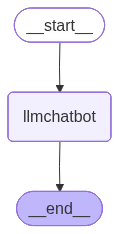

In [20]:
## Visualize the graph
from IPython.display import Image,display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass


In [21]:
response=graph.invoke({"messages":"Hi"})

In [22]:
response["messages"][-1].content

"It's nice to meet you. Is there something I can help you with or would you like to chat?"

In [23]:
for event in graph.stream({"messages":"Hi How are you?"}):
    for value in event.values():
        print(value["messages"][-1].content)

Hello. I'm just a language model, so I don't have feelings or emotions like humans do, but I'm functioning properly and ready to help with any questions or tasks you might have. How can I assist you today?


### Chatbot With Tool

In [24]:
from langchain_tavily import TavilySearch

tool=TavilySearch(max_results=2)
tool.invoke("What is langgraph?")

{'query': 'What is langgraph?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.ibm.com/think/topics/langgraph',
   'title': 'What is LangGraph? - IBM',
   'content': 'LangGraph, created by LangChain, is an open source AI agent framework designed to build, deploy and manage complex generative AI agent workflows. At its core, LangGraph uses the power of graph-based architectures to model and manage the intricate relationships between various components of an AI agent workflow. LangGraph illuminates the processes within an AI workflow, allowing full transparency of the agent’s state. By combining these technologies with a set of APIs and tools, LangGraph provides users with a versatile platform for developing AI solutions and workflows including chatbots, state graphs and other agent-based systems. **Nodes**: In LangGraph, nodes represent individual components or agents within an AI workflow. LangGraph uses enhanced decision-making by model

In [25]:
## Custom function
def multiply(a:int,b:int):
    """
    Multiply a and b

    Args:
        a (int): first int
        b (int): second int

    Returns:
        int: output int

    """
    return a*b

In [26]:
tools=[tool,multiply]

In [27]:
llm_with_tools=llm.bind_tools(tools)

In [28]:
llm_with_tools

RunnableBinding(bound=ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x787ce1585ca0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x787ce173b3e0>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********')), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, and trusted results. Useful for when you need to answer questions about current events. It not only retrieves URLs and snippets, but offers advanced search depths, domain management, time range filters, and image search, this tool delivers real-time, accurate, and citation-backed results.Input should 

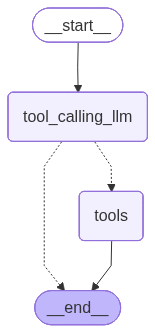

In [29]:
## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

## Graph
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

# Add Edges
builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    tools_condition
)
builder.add_edge("tool_calling_llm",END)

## Compile and visualize
graph=builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [30]:
response=graph.invoke({"messages":"What is the recent ai news?"})

In [31]:
response["messages"][-1].content

'{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.bloomberg.com/news/articles/2026-03-10/yann-lecun-s-new-ai-startup-raises-1-billion-in-seed-funding", "title": "Yann LeCun’s New AI Startup Raises $1 Billion in Seed Funding - Bloomberg.com", "score": 0.98228765, "published_date": "Tue, 10 Mar 2026 05:00:11 GMT", "content": "# Yann LeCun’s New AI Startup Raises $1 Billion in Seed Funding. Provide news feedback or report an error. Send a tip to our reporters. ### **Takeaways** by Bloomberg AISubscribe. Yann LeCun, a pioneer in the field of artificial intelligence, has raised $1.03 billion for a nascent startup that promises to invent technology more capable of navigating the real world than existing AI products like ChatGPT. The startup, which is not yet three months old, is called Advanced Machine Intelligence, or AMI, and reached a valuation of $3.5 billion in the funding round, not including dollars raised. Before 

In [32]:
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is the recent ai news?
================================== Ai Message ==================================
Tool Calls:
  tavily_search (zhwkfwm3h)
 Call ID: zhwkfwm3h
  Args:
    query: recent AI news
    time_range: day
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.bloomberg.com/news/articles/2026-03-10/yann-lecun-s-new-ai-startup-raises-1-billion-in-seed-funding", "title": "Yann LeCun’s New AI Startup Raises $1 Billion in Seed Funding - Bloomberg.com", "score": 0.98228765, "published_date": "Tue, 10 Mar 2026 05:00:11 GMT", "content": "# Yann LeCun’s New AI Startup Raises $1 Billion in Seed Funding. Provide news feedback or report an error. Send a tip to our reporters. ### **Takeaways** by Bloomberg AISubscribe. Y

In [27]:
response=graph.invoke({"messages":"What is 5 multiplied by 2 and then multiply by 2"})
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is 5 multiplied by 2 and then multiply by 2
================================== Ai Message ==================================
Tool Calls:
  multiply (fdg49n33b)
 Call ID: fdg49n33b
  Args:
    a: 5
    b: 2
================================= Tool Message =================================
Name: multiply

10


### ReAct Agent Architecture

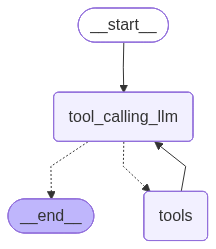

In [33]:
## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

## Graph
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

# Add Edges
builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")

## Compile and visualize
graph=builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [34]:
response=graph.invoke({"messages":"Give me the recent ai news and then multiply 5 by 10"})
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

Give me the recent ai news and then multiply 5 by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (aqajakvnn)
 Call ID: aqajakvnn
  Args:
    query: recent AI news
    time_range: day
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.bloomberg.com/news/articles/2026-03-10/yann-lecun-s-new-ai-startup-raises-1-billion-in-seed-funding", "title": "Yann LeCun’s New AI Startup Raises $1 Billion in Seed Funding - Bloomberg.com", "score": 0.98228765, "published_date": "Tue, 10 Mar 2026 05:00:11 GMT", "content": "# Yann LeCun’s New AI Startup Raises $1 Billion in Seed Funding. Provide news feedback or report an error. Send a tip to our reporters. ### **Takeaways** by

### Adding Memory In Agentic Graph

In [35]:
response=graph.invoke({"messages":"Hello my name is Frank"})
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

Hello my name is Frank
================================== Ai Message ==================================

It's nice to meet you, Frank. Is there something I can help you with or would you like to chat?


In [36]:
response=graph.invoke({"messages":"What is my name"})
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is my name
================================== Ai Message ==================================

I don't have any information about your name. This conversation just started, and I don't have any prior knowledge about you. If you'd like to share your name, I'd be happy to chat with you!


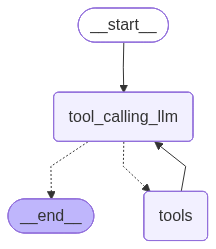

In [37]:
## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

## Graph
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

# Add Edges
builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")

## Compile and visualize
graph=builder.compile(checkpointer=memory)

display(Image(graph.get_graph().draw_mermaid_png()))

In [38]:
config={"configurable":{"thread_id":"1"}}
response=graph.invoke({"messages":"Hi my name is Frank"},config=config)
response

{'messages': [HumanMessage(content='Hi my name is Frank', additional_kwargs={}, response_metadata={}, id='433f5f4f-3102-4afd-bc4d-18d525167769'),
  AIMessage(content="It's nice to meet you, Frank. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 25, 'prompt_tokens': 1750, 'total_tokens': 1775, 'completion_time': 0.066394295, 'completion_tokens_details': None, 'prompt_time': 0.093674506, 'prompt_tokens_details': None, 'queue_time': 0.048506261, 'total_time': 0.160068801}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_f8b414701e', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019cd994-3570-7922-bf95-84f7455abb63-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1750, 'output_tokens': 25, 'total_tokens': 1775})]}

In [40]:
response["messages"][-1].content

"It's nice to meet you, Frank. Is there something I can help you with or would you like to chat?"

In [41]:
config={"configurable":{"thread_id":"1"}}
response=graph.invoke({"messages":"Hey what is my name?"},config=config)
print(response["messages"][-1].content)

Your name is Frank.


In [42]:
config={"configurable":{"thread_id":"1"}}
response=graph.invoke({"messages":"Hey do you remember me?"},config=config)
print(response["messages"][-1].content)

Yes, I remember you. Your name is Frank. We just started talking, so I haven't forgotten you yet.


### Stream

In [43]:
from langgraph.checkpoint.memory import MemorySaver
memory=MemorySaver()

In [44]:
def superbot(state:State):
    return {"messages":[llm.invoke(state["messages"])]}

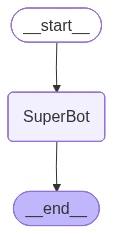

In [45]:
graph=StateGraph(State)

## node
graph.add_node("SuperBot",superbot)

## Edges
graph.add_edge(START,"SuperBot")
graph.add_edge("SuperBot",END)

graph_builder=graph.compile(checkpointer=memory)

## Visualize the graph
from IPython.display import Image,display
display(Image(graph_builder.get_graph().draw_mermaid_png()))


In [46]:
## Invoke the graph

config={"configurable":{"thread_id":"1"}}
graph_builder.invoke({"messages":"Hi, My name is Frank and I like marathon running."},config)

{'messages': [HumanMessage(content='Hi, My name is Frank and I like marathon running.', additional_kwargs={}, response_metadata={}, id='b6829d63-9f7f-45b4-889f-bd4be179998b'),
  AIMessage(content='Nice to meet you, Frank. Marathon running is a great hobby that requires a lot of dedication and perseverance. What got you into marathon running, and do you have a favorite marathon or running route that you enjoy?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 44, 'prompt_tokens': 47, 'total_tokens': 91, 'completion_time': 0.126563363, 'completion_tokens_details': None, 'prompt_time': 0.001432503, 'prompt_tokens_details': None, 'queue_time': 0.042781365, 'total_time': 0.127995866}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_f8b414701e', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019cd994-bcb0-7010-8e3c-a21c34787e55-0', tool_calls=[], invalid_tool_calls=[], usage_metad

In [47]:
# Create a new conversation thread

config={"configurable":{"thread_id":"3"}}

for chunk in graph_builder.stream({"messages":"Hi,My name is Frank and I like marathon"},config,stream_mode="updates"):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content="Nice to meet you, Frank. That's great that you enjoy marathons. Are you a runner yourself, or do you enjoy watching marathon events? What is it about marathons that you like the most? Is it the challenge, the sense of accomplishment, or something else?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 59, 'prompt_tokens': 45, 'total_tokens': 104, 'completion_time': 0.150903085, 'completion_tokens_details': None, 'prompt_time': 0.012516969, 'prompt_tokens_details': None, 'queue_time': 0.048536353, 'total_time': 0.163420054}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_f8b414701e', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019cd994-d464-7852-a635-d4b2cfdb59cc-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 45, 'output_tokens': 59, 'total_tokens': 104})]}}


In [48]:
for chunk in graph_builder.stream({"messages":"Hi,My name is Frank and I like marathon"},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi,My name is Frank and I like marathon', additional_kwargs={}, response_metadata={}, id='a40a3181-cef5-43a0-a161-2049ac4192cb'), AIMessage(content="Nice to meet you, Frank. That's great that you enjoy marathons. Are you a runner yourself, or do you enjoy watching marathon events? What is it about marathons that you like the most? Is it the challenge, the sense of accomplishment, or something else?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 59, 'prompt_tokens': 45, 'total_tokens': 104, 'completion_time': 0.150903085, 'completion_tokens_details': None, 'prompt_time': 0.012516969, 'prompt_tokens_details': None, 'queue_time': 0.048536353, 'total_time': 0.163420054}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_f8b414701e', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019cd994-d464-7852-a635-d4b2cfdb59cc-0', tool_calls=[], invalid_

In [49]:
# Create a new conversation thread

config={"configurable":{"thread_id":"4"}}

for chunk in graph_builder.stream({"messages":"Hi,My name is Frank and I like marathon"},config,stream_mode="updates"):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content='Nice to meet you, Frank. Marathon running is an impressive and challenging hobby. It requires a lot of dedication, discipline, and physical endurance. What is it about marathon running that you enjoy the most? Is it the sense of accomplishment when you cross the finish line, the thrill of competition, or the physical and mental challenge of pushing yourself to your limits?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 73, 'prompt_tokens': 45, 'total_tokens': 118, 'completion_time': 0.219738763, 'completion_tokens_details': None, 'prompt_time': 0.002457512, 'prompt_tokens_details': None, 'queue_time': 0.042538449, 'total_time': 0.222196275}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_f8b414701e', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019cd994-f168-76b3-8502-7456c824c397-0', tool_calls=[], invalid_tool_calls=[], u

In [50]:
for chunk in graph_builder.stream({"messages":"I also like football"},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi,My name is Frank and I like marathon', additional_kwargs={}, response_metadata={}, id='9af7bd4d-d432-4699-a9b9-ca373e5c44cc'), AIMessage(content='Nice to meet you, Frank. Marathon running is an impressive and challenging hobby. It requires a lot of dedication, discipline, and physical endurance. What is it about marathon running that you enjoy the most? Is it the sense of accomplishment when you cross the finish line, the thrill of competition, or the physical and mental challenge of pushing yourself to your limits?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 73, 'prompt_tokens': 45, 'total_tokens': 118, 'completion_time': 0.219738763, 'completion_tokens_details': None, 'prompt_time': 0.002457512, 'prompt_tokens_details': None, 'queue_time': 0.042538449, 'total_time': 0.222196275}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_f8b414701e', 'service_tier': 'on_demand', 'finish_reason': 'stop'

In [52]:
# Create a new conversation thread

config={"configurable":{"thread_id":"4"}}

async for event in graph_builder.astream_events({"messages":"Hi,My name is Frank and I like marathon"},config,version="v2"):
    print(event)

{'event': 'on_chain_start', 'data': {'input': {'messages': 'Hi,My name is Frank and I like marathon'}}, 'name': 'LangGraph', 'tags': [], 'run_id': '019cd9a9-fdbb-7b02-948b-ce617ceb27c2', 'metadata': {'thread_id': '4'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='Hi,My name is Frank and I like marathon', additional_kwargs={}, response_metadata={}, id='9af7bd4d-d432-4699-a9b9-ca373e5c44cc'), AIMessage(content='Nice to meet you, Frank. Marathon running is an impressive and challenging hobby. It requires a lot of dedication, discipline, and physical endurance. What is it about marathon running that you enjoy the most? Is it the sense of accomplishment when you cross the finish line, the thrill of competition, or the physical and mental challenge of pushing yourself to your limits?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 73, 'prompt_tokens': 45, 'total_tokens': 118, 'completion_time': 0.219738763

### Human In the Loop

In [63]:
import os
from langchain.chat_models import init_chat_model
llm=init_chat_model("groq:llama-3.3-70b-versatile")
llm

ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x787ccf6904a0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x787ce12fb140>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [66]:
from typing import Annotated

from langchain_tavily import TavilySearch
from langchain_core.tools import tool
from typing_extensions import TypedDict

from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition

from langgraph.types import Command, interrupt

class State(TypedDict):
    messages:Annotated[list,add_messages]
graph_builder=StateGraph(State)

@tool
def human_assistance(query:str)->str:
    """Request assistance from a human."""
    human_response=interrupt({"query":query})
    return human_response["data"]

tool=TavilySearch(max_results=2)
tools=[tool,human_assistance]
llm_with_tools=llm.bind_tools(tools)

def chatbot(state:State):
    message=llm_with_tools.invoke(state["messages"])
    return {"messages":[message]}

graph_builder.add_node("chatbot",chatbot)

tool_node=ToolNode(tools=tools)
graph_builder.add_node("tools",tool_node)

graph_builder.add_conditional_edges("chatbot",tools_condition)

graph_builder.add_edge("tools","chatbot")
graph_builder.add_edge(START,"chatbot")

In [67]:
memory=MemorySaver()
graph=graph_builder.compile(checkpointer=memory)

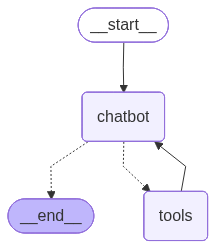

In [68]:
from IPython.display import Image,display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [69]:
user_input="I need some expert guidance for building an AI agent. Could you request assistance for me?"
config={"configurable":{"thread_id":"1"}}

events=graph.stream({"messages":user_input},config,stream_mode="values")
for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================ Human Message =================================

I need some expert guidance for building an AI agent. Could you request assistance for me?
================================== Ai Message ==================================
Tool Calls:
  human_assistance (23t1t2xc9)
 Call ID: 23t1t2xc9
  Args:
    query: expert guidance for building an AI agent
================================== Ai Message ==================================
Tool Calls:
  human_assistance (23t1t2xc9)
 Call ID: 23t1t2xc9
  Args:
    query: expert guidance for building an AI agent


In [70]:
human_response=(
    "We, the experts are here to help! We'd recommend you check out LangGraph to build your agent."
    "It's much more reliable and extensible than simple autonomous agents."
)

human_command=Command(resume={"data":human_response})

events=graph.stream(human_command,config,stream_mode="values")
for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================== Ai Message ==================================
Tool Calls:
  human_assistance (23t1t2xc9)
 Call ID: 23t1t2xc9
  Args:
    query: expert guidance for building an AI agent
================================= Tool Message =================================
Name: human_assistance

We, the experts are here to help! We'd recommend you check out LangGraph to build your agent.It's much more reliable and extensible than simple autonomous agents.
================================== Ai Message ==================================

I hope the provided guidance is helpful for building your AI agent. If you have more specific questions or would like to know more about the LangGraph, feel free to ask.
